# Lab 1 — Interpretable by Design Models
**Teaching assistant** : Eleonora Poeta (eleonora.poeta@polito.it)

---

This lab covers three **interpretable-by-design** classifiers and how to extract meaningful explanations from each:

| Model | Interpretability type |
|---|---|
| **Decision Tree** | Global (tree structure, feature importance, depth trade-off) + Local (decision path) |
| **Logistic Regression** | Global (coefficients, odds ratios, correlation matrix) |
| **K-Nearest Neighbors** | Local (example-based, neighbor inspection + visualisation) |

**Guide:**
- ⚙️ Preprocessing recap
- 🌳 Decision Tree
- 📈 Logistic Regression
- 👥 KNN

---

## ⚙️ Preprocessing Recap (~10 min)

We are using the **Diabetes prediction dataset** and the same pipeline from Lab 0.
Rather than stepping through every operation again, this section is structured as a **quick recap** —
each cell highlights one key concept with a reminder of *why* it matters.

> 💡 The goal here is to consolidate what you learned in Lab 0, not to learn new things!
> By the end of this section you should be able to answer: *what would go wrong if you skipped each step?*

### ⚙️ Step 1 — Imports & Load

In [1]:
"""
from google.colab import drive
drive.mount('/content/drive')
"""

"\nfrom google.colab import drive\ndrive.mount('/content/drive')\n"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree

# ── Load the dataset ──────────────────────────────────────────────────────────
# Uncomment the line that matches your environment:
df = pd.read_csv('./diabetes.csv')

df.columns = [c.lower().replace('-', '_') for c in df.columns]
if 'class' in df.columns:
    df.rename(columns={'class': 'diabetes'}, inplace=True)
df['diabetes'] = df['diabetes'].astype(int)

print(f"Loaded {len(df)} rows  |  Columns: {df.columns.tolist()}")
df.head()

Loaded 100000 rows  |  Columns: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hba1c_level', 'blood_glucose_level', 'diabetes']


,gender,age,hypertension,heart_disease,smoking_history,bmi,hba1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


### ⚙️ Step 2 — Check Class Balance & Duplicates

> 🔑 **Key reminder:** an imbalanced dataset means **accuracy is a misleading metric**.
> If 91% of patients are non-diabetic, a model that always predicts "no diabetes" gets 91% accuracy — and is completely useless.
> Always check balance *before* splitting so you can choose `stratify=` and the right evaluation metric.

In [3]:
print("Class distribution:")
print(df['diabetes'].value_counts())
print(f"\nImbalance ratio: {df['diabetes'].value_counts()[0] / df['diabetes'].value_counts()[1]:.1f}:1")

# Duplicates
n_dupes = df.duplicated(keep='first').sum()
print(f"\nDuplicate rows: {n_dupes}")
df.drop_duplicates(inplace=True, keep='first')
print(f"Rows after dedup: {len(df)}")

Class distribution:
diabetes
0    91500
1     8500
Name: count, dtype: int64

Imbalance ratio: 10.8:1

Duplicate rows: 3854
Rows after dedup: 96146


### ⚙️ Step 3 — Stratified Train/Test Split

> 🔑 **Key reminder:** split *before* any transformation. Fitting scalers or encoders
> on the full dataset lets test-set statistics leak into your preprocessing, making
> your evaluation overly optimistic — this is called **data leakage**.
> `stratify=` preserves the class ratio in both subsets.

In [4]:
df_train, df_test = train_test_split(
    df, test_size=0.2, shuffle=True, random_state=42, stratify=df['diabetes'])

print(f"Train: {len(df_train)} rows  |  Test: {len(df_test)} rows")
print(f"\nTrain class balance:\n{df_train['diabetes'].value_counts()}")
print(f"\nTest class balance:\n{df_test['diabetes'].value_counts()}")

Train: 76916 rows  |  Test: 19230 rows

Train class balance:
diabetes
0    70130
1     6786
Name: count, dtype: int64

Test class balance:
diabetes
0    17534
1     1696
Name: count, dtype: int64


### ⚙️ Step 4 — Feature Engineering & Encoding

> 🔑 **Key reminder:** ML models need numbers. Categorical features must be encoded,
> but the *type* of encoding matters:
> - **Ordinal Encoder** — when categories have a natural order (e.g. Child < Young < Adult < Senior)
> - **One-Hot Encoder** — when categories have no order (e.g. gender)
> Using the wrong encoder imposes false numeric relationships the model will exploit.

In [5]:
# ── Discretize age into 4 ordered bins ───────────────────────────────────────
age_bins   = [0, 14, 24, 50, 100]
age_labels = ['Child (0-14]', 'Young (14-24]', 'Adults (24-50]', 'Senior (50+]']
for d in [df_train, df_test]:
    d['age_disc'] = pd.cut(d['age'], bins=age_bins, labels=age_labels)
    d.drop(columns=['age'], inplace=True)

# ── Merge sparse smoking categories ──────────────────────────────────────────
# 'former' and 'not current' mean the same thing — combining them avoids sparse encoding
for d in [df_train, df_test]:
    d.loc[d['smoking_history'] == 'former', 'smoking_history'] = 'not current'

# ── Remove rare 'Other' gender rows (too few to encode reliably) ──────────────
df_train = df_train[df_train['gender'] != 'Other'].copy()
df_test  = df_test[df_test['gender']  != 'Other'].copy()

# ── Ordinal encode: smoking_history and age_disc (both have natural order) ────
smoking_order = ["never", "not current", "No Info", "current", "ever"]
ord_enc = OrdinalEncoder(categories=[smoking_order, age_labels])
ord_enc.fit(df_train[['smoking_history', 'age_disc']])   # fit on train only!
for d in [df_train, df_test]:
    d[['smoking_history', 'age_disc']] = ord_enc.transform(d[['smoking_history', 'age_disc']])

# ── One-hot encode: gender (no natural order) ─────────────────────────────────
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(df_train[['gender']])                             # fit on train only!
for d in [df_train, df_test]:
    ohe_cols = pd.DataFrame(ohe.transform(d[['gender']]),
                            columns=ohe.get_feature_names_out(), index=d.index)
    d.drop(columns=['gender'], inplace=True)
    for col in ohe_cols.columns:
        d[col] = ohe_cols[col]

print("Encoding done. Columns:", df_train.columns.tolist())
df_train.head(3)

Encoding done. Columns: ['hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hba1c_level', 'blood_glucose_level', 'diabetes', 'age_disc', 'gender_Female', 'gender_Male']


,hypertension,heart_disease,smoking_history,bmi,hba1c_level,blood_glucose_level,diabetes,age_disc,gender_Female,gender_Male
79000,0,0,2.0,23.87,5.7,126,0,2.0,0.0,1.0
32011,0,0,1.0,33.03,4.0,126,0,3.0,1.0,0.0
95559,0,0,2.0,27.32,6.6,126,0,2.0,1.0,0.0


### ⚙️ Step 5 — Scaling & Final Split

> 🔑 **Key reminder:** scaling is essential for distance-based models (KNN) and
> gradient-based models (Logistic Regression), which are sensitive to feature magnitude.
> Decision trees are *scale-invariant* — they only care about split thresholds, not absolute values.
> We scale anyway so all three models share the same `X_train` / `X_test`.

In [6]:
scale_cols = ['bmi', 'hba1c_level', 'blood_glucose_level', 'age_disc', 'smoking_history']

scaler = MinMaxScaler()
df_train[scale_cols] = scaler.fit_transform(df_train[scale_cols])  # fit on train only!
df_test[scale_cols]  = scaler.transform(df_test[scale_cols])

# ── Extract X / y ─────────────────────────────────────────────────────────────
y_train = df_train['diabetes'];  X_train = df_train.drop('diabetes', axis=1)
y_test  = df_test['diabetes'];   X_test  = df_test.drop('diabetes',  axis=1)
feature_names = X_train.columns.tolist()

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Features: {feature_names}")

X_train: (76902, 9)  |  X_test: (19226, 9)
Features: ['hypertension', 'heart_disease', 'smoking_history', 'bmi', 'hba1c_level', 'blood_glucose_level', 'age_disc', 'gender_Female', 'gender_Male']


> ✅ **Preprocessing complete.** The three rules to always remember:
> 1. Split *before* fitting any transformer
> 2. Fit transformers on training data only, then `.transform()` both sets
> 3. Choose your encoding based on whether categories have a natural order

---

## Exercise 1 — Decision Tree 🌳

Decision trees are **interpretable by design**: the tree structure *is* the explanation — no separate explanation method needed.

They give a **transparent** and **intuitive** representation of the decision-making
process followed by the model. This transparency allows domain experts to easily
understand and validate the model's predictions.

---

**Global interpretability** — inspecting the whole tree. . The measures for the global interpretability are:
- **Depth** → shallower = simpler, more interpretable
- **Node count / splits** → proxy for complexity. A larger tree with more nodes and splits may capture intricate
patterns in the data but could also lead to overtting and decreased
interpretability
- **Feature importances** → which features drive most decisions (via Gini impurity reduction)

**Local interpretability** — local path for a single prediction.Then, as mesures for the local interpretability there is:
- **Length of the decision path** → the exact sequence of rules that routed this instance to its leaf

### Your tasks
1. Fit a `DecisionTreeClassifier`.
  
> * Visualize the decision tree obtained. Are you able to interpret the decision
> * Try again with `max_depth=4` and compare the two trees. Which one is the
  most interpretable?

2. Analyze **Global Interpretability**:
Continue visualizing the obtained decision tree with `max_depth=4` .

> * Which attributes are the **most discriminating**? Plot the feature importances and then analyze the values.
> * Calculate the size of the decision tree in terms of the number of nodes,
subdivisions, and depth. How these metrics affect the interpretability of the
decision tree globally?

3. Analyze **Local Interpretability**:
Consider the instances *100, 150 and 200* of the train dataset.

> * What are the individual paths? What are the instances allocated in the
paths?
> * For each of the previous instances, calculate the **length** of each path from
the root node to the leaf node to which the instance belongs. How the
length of these paths contributes to the interpretability of the decision tree
locally?

### 1.1 — Fit & Visualise

Classification report for None:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     17530
           1       0.72      0.74      0.73      1696

    accuracy                           0.95     19226
   macro avg       0.85      0.86      0.85     19226
weighted avg       0.95      0.95      0.95     19226

Classification report for 4:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17530
           1       1.00      0.68      0.81      1696

    accuracy                           0.97     19226
   macro avg       0.98      0.84      0.90     19226
weighted avg       0.97      0.97      0.97     19226



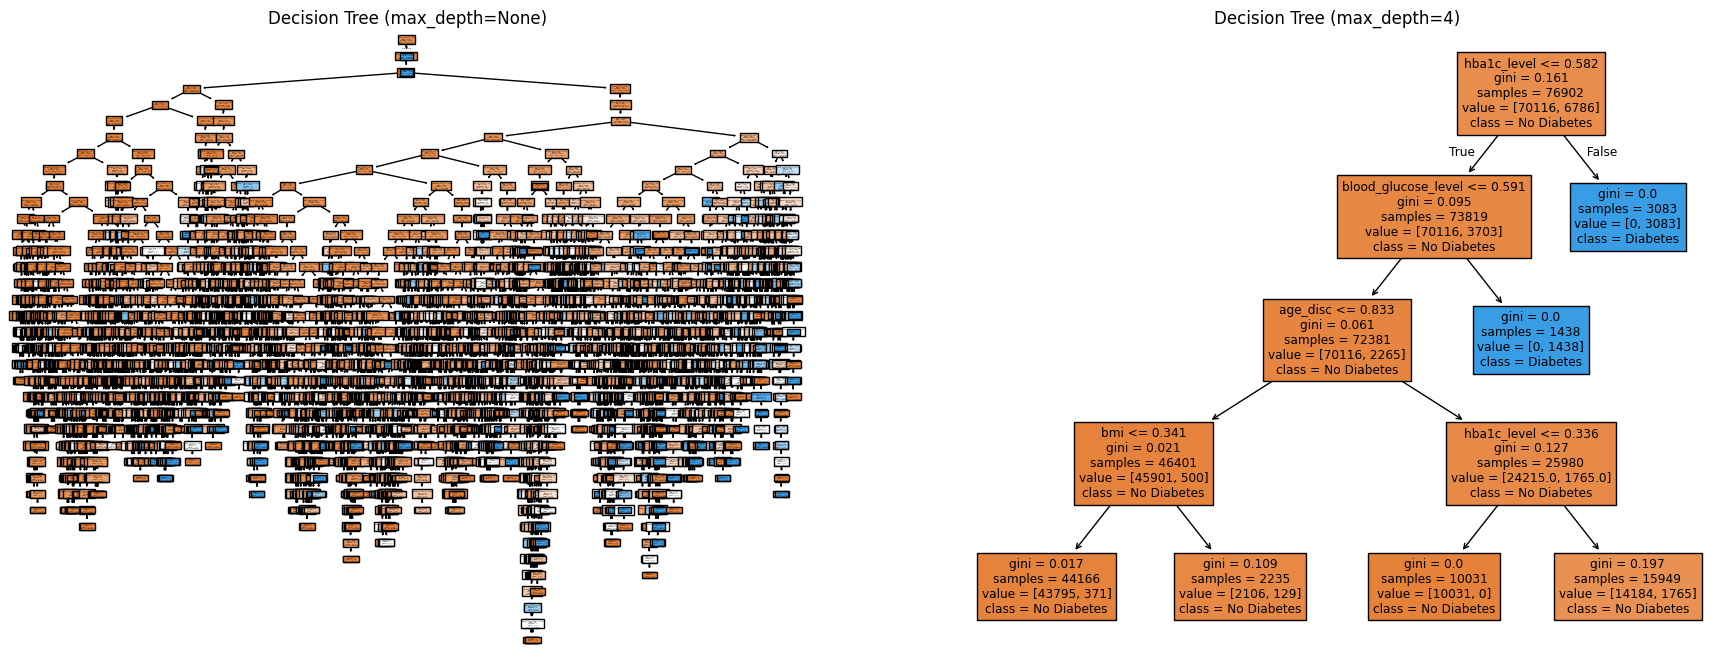

In [7]:
#### START CODE HERE ####
from sklearn.tree import DecisionTreeClassifier

depths = [None, 4]
models = {}

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"Classification report for {d}:\n{classification_report(y_test, preds)}")
    models[d] = model

# This is the code to plot the decision tree dt
plt.figure(figsize=(22, 8))
for i, d in enumerate(depths):
    plt.subplot(1, len(depths), i+1)
    tree.plot_tree(models[d], feature_names=feature_names, class_names=['No Diabetes', 'Diabetes'], filled=True)
    plt.title(f"Decision Tree (max_depth={d})")
plt.show()
#### END CODE HERE ####

### 1.2 — Max Depth 4

In [8]:
#### START CODE HERE -- Decision Tree max_depth=4 ####
dt = models[4]  # max_depth=4
y_pred = dt.predict(X_test)
print("Classification Report for Decision Tree (max_depth=4):")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))
#### END CODE HERE ####

Classification Report for Decision Tree (max_depth=4):
              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     17530
    Diabetes       1.00      0.68      0.81      1696

    accuracy                           0.97     19226
   macro avg       0.98      0.84      0.90     19226
weighted avg       0.97      0.97      0.97     19226



### 1.3 — Global Interpretability

In [9]:
#### START CODE HERE -- Decision Tree Global Interpretability ####
importances = dt.feature_importances_
importance_dictionary = {feat: importances[i] for i, feat in enumerate(X_train.columns)}
for e in dict(sorted(importance_dictionary.items(), key=lambda item: item[1], reverse=True)).items():
    print(e)
#### END CODE HERE ####

('hba1c_level', np.float64(0.6650457510459421))
('blood_glucose_level', np.float64(0.3205183172380393))
('age_disc', np.float64(0.013182497625855268))
('bmi', np.float64(0.0012534340901632652))
('hypertension', np.float64(0.0))
('heart_disease', np.float64(0.0))
('smoking_history', np.float64(0.0))
('gender_Female', np.float64(0.0))
('gender_Male', np.float64(0.0))


### 1.4 — Local Interpretability: Decision Paths

In [10]:
#### START CODE HERE -- Decision Tree Local Interpretability ####
# Example: explain the 100, 150 and 200 in the train set
for idx in [100, 150, 200]:
    # Get the instance to explain
    instance = X_train.iloc[[idx]]

    # Get the prediction for this instance
    pred = dt.predict(instance)

    # Get the decision path for this instance
    decision_path = dt.decision_path(instance)
    print(decision_path.indices)

    # Get the length of the path (number of nodes visited)
    path_length = decision_path.indices.shape[0]
    print(f"Instance {idx} - Predicted class: {pred[0]} - Path length: {path_length}")
#### END CODE HERE ####

[ 0 10]
Instance 100 - Predicted class: 1 - Path length: 2
[0 1 2 6 8]
Instance 150 - Predicted class: 0 - Path length: 5
[0 1 2 3 4]
Instance 200 - Predicted class: 0 - Path length: 5


> **Reflection:** Look at the path lengths for your three instances. A shorter path means fewer rules were needed — usually a more "clear-cut" case. Do instances with shorter paths have more extreme feature values (very high blood glucose, very high HbA1c)?

---

## Exercise 2 — Logistic Regression 📈

Logistic Regression is interpretable through its **coefficients** and derived **odds ratios**.
Unlike Linear regression, the interpretation of logistic regression weights varies since the outcome in logistic regression is a probability confined within the range of 0 to 1.
These weights undergo transformation through the logistic function, influencing the probability non-linearly.

- **Coefficient > 0** → feature increases the log-odds of the positive class (diabetes)
- **Coefficient < 0** → feature decreases the log-odds
- **Odds ratio = exp(coef)** → multiplicative change in odds for a 1-unit increase in the feature
  - OR > 1 → increases odds of diabetes
  - OR < 1 → decreases odds of diabetes
  - OR = 1 → no effect

### Your tasks
1.   Fit a [**Logistic Regression**](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression) model on the same dataset as before.

2.  Compute the Correlation Matrix.

3.  Evaluate the model using Precision, Recall and F1-score metrics.

4.  Analyze **Interpretability**:


> * Visualize the estimated **weights** and **odds ratios** obtained from logistic regression for each feature.
> * Put them into a tabular form and interpret the logistic regression model for different types of features. Specifically, analyze the ***bmi*** feature and ***gender_Male*** and ***gender_Female*** features.


### 2.1 — Fit & Evaluate

In [11]:
from sklearn.linear_model import LogisticRegression

#### START CODE HERE ####
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
preds = lr.predict(X_test)
print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test, preds, target_names=['No Diabetes', 'Diabetes']))
#### END CODE HERE ####


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

 No Diabetes       0.96      0.99      0.98     17530
    Diabetes       0.87      0.63      0.73      1696

    accuracy                           0.96     19226
   macro avg       0.92      0.81      0.85     19226
weighted avg       0.96      0.96      0.96     19226



### 2.2 — Correlation Matrix

> 🔑 Before interpreting coefficients, always check for **multicollinearity** — when two features are
> highly correlated, the model distributes their shared explanatory power between them arbitrarily.
> This makes individual coefficients unreliable as explanations, even if the model's predictions are fine.

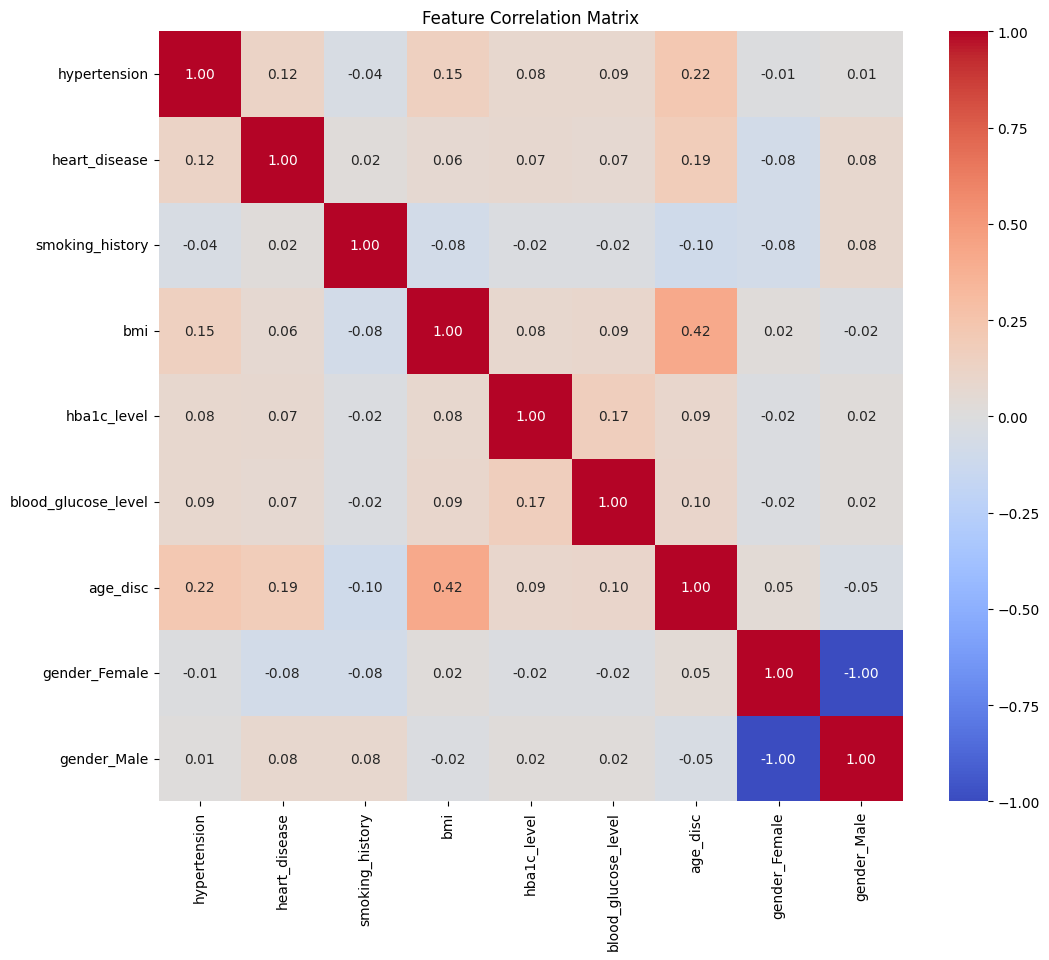

In [12]:
#### START CODE HERE ####
# Correlation matrix
corr_matrix = X_train.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Feature Correlation Matrix")
plt.show()
#### END CODE HERE ####

### 2.3 — Coefficients Weights & Odds Ratios

In [13]:
#### START CODE HERE ####
# Logistic Regression Coefficients
coeffs = pd.DataFrame({
    'Feature': feature_names,
    'Coef': lr.coef_[0]
})
coeffs = coeffs.sort_values('Coef', key=abs, ascending=False)
coeffs
#### END CODE HERE ####

,Feature,Coef
4,hba1c_level,12.056529
5,blood_glucose_level,7.138984
3,bmi,6.179285
7,gender_Female,-4.783915
8,gender_Male,-4.494888
6,age_disc,3.441471
1,heart_disease,0.932194
0,hypertension,0.876700
2,smoking_history,-0.256792


## Exercise 3 — K-Nearest Neighbors 👥

KNN is an **instance-based learner**: there are no learned weights or tree structures to inspect.
In KNN, the prediction for a new data point is determined by the **majority** **class** (for classification) or the **mean** of the closest k neighbors' values (for regression) among the training data points, where *k* is a user-defined parameter.


Finding *k* can be tricky and you typically use techniques like cross-validation, **grid search**, or random search.

The interpretation and explanation of KNN does not follow procedures similar to the ones above. This because the KNN is an **instance-based learning algorithm** and so the interpretability comes entirely from **looking at the neighbors** used to make a prediction:

> *"This patient is predicted diabetic because their **6 most similar** patients in the training set were all diabetic."*


Hence, to explain a prediction in KNN:


1.   Retrieve the *k neighbors* that were used for the prediction.
2.   Analyze the k neighbors.

Hence, this is **purely local** interpretability — each prediction gets its own explanation given by its closest example.

### Your tasks

1. Find the best `k` parameter iterating over a range (1, 15) using a [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

> * Use the **best k** already found and fit a [**KNN**](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) on the same dataset as before.

> * Evaluate the KNN calculating the **mean accuracy** over test dataset.

2. Analyze **Interpretability** explaining 3 instances:

> * Consider the instances 100, 150 and 200 of the train dataset.
> * **Check** the **predicted target** for each instance.
> * **Retrieve** the relative k-nearest neighbors.
> * To **explain** the **predicted target** check the predicted targets for each of the k-nearest neighbors.

### 3.1 — Grid Search for Best K

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

#### START CODE HERE ####
param_grid = {'n_neighbors': range(1, 15)}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid=param_grid, cv=5)

grid_search.fit(X_train, y_train)
print(f"Best K: {grid_search.best_params_['n_neighbors']}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")
#### END CODE HERE ####

Best K: 6
Best CV Score: 0.9629


### 3.2 — Mean Accuracy over test dataset

In [21]:
#### START CODE HERE ####
# Mean Acccuracy over the test set
print(f"Classification Report for KNN:\n\n{classification_report(y_test, grid_search.predict(X_test))}")
print(f"Confusion Matrix for KNN:\n{confusion_matrix(y_test, grid_search.predict(X_test))}")
#### END CODE HERE ####

Classification Report for KNN:

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     17530
           1       0.96      0.61      0.75      1696

    accuracy                           0.96     19226
   macro avg       0.96      0.81      0.86     19226
weighted avg       0.96      0.96      0.96     19226

Confusion Matrix for KNN:
[[17487    43]
 [  654  1042]]


### 3.3 — Explain 3 instances


In [33]:
#### START CODE HERE ####
# Consider the 100, 150 and 200 in the train set
for idx in [100, 150, 200]:
    instance = X_train.iloc[[idx]]
    pred = grid_search.predict(instance)[0]
    print(f"\nInstance index: {idx}  |  Predicted class by KNN: {pred}")

    # Check nearest neighbors
    neighbors = grid_search.best_estimator_.kneighbors(instance, return_distance=False)
    print(f"Nearest neighbors indices: {neighbors[0]}")
    print(f"Nearest neighbors classes:\n{y_train.iloc[neighbors[0]]}")
#### END CODE HERE ####


Instance index: 100  |  Predicted class by KNN: 1
Nearest neighbors indices: [  100  4104 40521  6724  3293 35933]
Nearest neighbors classes:
96371    1
90797    1
51696    1
48413    1
70050    1
74568    1
Name: diabetes, dtype: int64

Instance index: 150  |  Predicted class by KNN: 0
Nearest neighbors indices: [  150  6295 24864  8900 13797  9532]
Nearest neighbors classes:
3969     0
93181    0
232      0
67989    0
46041    0
76634    0
Name: diabetes, dtype: int64

Instance index: 200  |  Predicted class by KNN: 0
Nearest neighbors indices: [  200 21412 40441 67989  8781 36045]
Nearest neighbors classes:
74316    0
59850    0
69390    0
36152    0
46371    0
33003    0
Name: diabetes, dtype: int64


### 🔍 Reflection Questions

1. **Decision Tree:** The depth–accuracy plot shows that depth=4 costs some performance. Is that trade-off justified for a medical application like diabetes prediction — and *who* needs to read this model (clinician? regulator? patient)?

2. **Logistic Regression:** `blood_glucose_level` and `HbA1c_level` are likely correlated. If both have large positive coefficients, can you trust either one in isolation as an explanation? What would you do before presenting these to a doctor?

3. **KNN:** When an instance's neighbors are split (e.g. 4 vs. 2), the model is less "certain". How could you expose that uncertainty meaningfully? Would a clinician trust a prediction backed by only 4 out of 6 neighbors?

4. **General:** All three models are "interpretable by design" — but is interpretability the same as trustworthiness? Can you construct a scenario where a shallow Decision Tree gives a confidently *wrong* explanation?